# Has the structure of risk in financial markets changed since COVID-19?

## Part 0 — Packages and helper functions

We import only what is needed. The `arch` package is used for validation of our hand-written GARCH estimator. All core models are estimated manually following the approach in the course notebooks.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

ANNUALIZATION = 252

In [14]:
DATA_PATH = "Data.xlsx"

prices = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True)
prices.index.name = "Date"
prices = prices.sort_index().ffill()
prices = prices.where(prices > 0).ffill()

prices.tail()

,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,7109.1401,5982.6299,26361.0703,1600.3800,13284.2197,4.2510,2.9801,89.61,4820.6602,1.1788,158.81,3619.0959,2699.5801,0.7784
2026-04-21,7064.0098,5930.2500,26487.4805,1615.4800,13134.1396,4.2916,3.0038,92.13,4720.0400,1.1744,159.37,3608.6770,2695.9480,0.7810
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.96,4739.8999,1.1705,159.48,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.85,4694.1401,1.1683,159.71,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.40,4709.5000,1.1722,159.38,3612.0129,2695.6079,0.7850


## Part 1 — Data loading and sample construction

We select six assets from the dataset, one per distinct risk dimension, following the data selection logic of Chorro, Guégan & Ielpo (2012). Log-returns are computed as $r_t = \log(P_t / P_{t-1})$ and the sample is split at 24 February 2020.

In [15]:
# One series per non-redundant risk dimension
# Excluded: yields (log-returns of near-zero yields are explosive),
# MSCI EM and Hang Seng (post-COVID correlation 0.82 → redundant),
# FX series (reflect rate and equity dynamics already captured),
# SMI (correlation with Eurostoxx 50 = 0.81)

ASSETS = ["S&P500", "Eurostoxx 50", "US IG Bonds", "US HY Bonds", "Gold", "Oil futures"]

prices = prices[ASSETS]
prices.tail()

,S&P500,Eurostoxx 50,US IG Bonds,US HY Bonds,Gold,Oil futures
Date,,,,,,
2026-04-20,7109.1401,5982.6299,3619.0959,2699.5801,4820.6602,89.61
2026-04-21,7064.0098,5930.2500,3608.6770,2695.9480,4720.0400,92.13
2026-04-22,7137.8999,5906.2202,3613.8870,2696.9160,4739.8999,92.96
2026-04-23,7108.3999,5894.7300,3608.3889,2694.0430,4694.1401,95.85
2026-04-24,7165.0801,5883.4800,3612.0129,2695.6079,4709.5000,94.40


### Missing values

Missing prices arise from different exchange calendars. We document the coverage per asset before forward-filling.

In [16]:
print(f"{'Asset':<20} {'Missing':>8}  {'First valid':>12}  {'Last valid':>12}")
print("-" * 58)
for col in ASSETS:
    n  = prices[col].isna().sum()
    fv = prices[col].first_valid_index().date()
    lv = prices[col].last_valid_index().date()
    print(f"{col:<20} {n:>8,}  {str(fv):>12}  {str(lv):>12}")

Asset                 Missing   First valid    Last valid
----------------------------------------------------------
S&P500                      2    1990-01-02    2026-04-24
Eurostoxx 50                1    1990-01-01    2026-04-24
US IG Bonds                 0    1989-12-31    2026-04-24
US HY Bonds                 0    1989-12-31    2026-04-24
Gold                        2    1990-01-02    2026-04-24
Oil futures                 2    1990-01-02    2026-04-24


### Log-returns and sample split

The COVID breakpoint is set at **24 February 2020** — the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days). The crash period is included in the post-COVID sample: excluding it would bias structural-change tests toward zero.

In [17]:
returns = np.log(prices).diff().dropna(how="all")

COVID_DATE = pd.Timestamp("2020-02-24")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"Full sample : {returns.index[0].date()} → {returns.index[-1].date()}  ({len(returns):,} obs)")
print(f"Pre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")

Full sample : 1990-01-01 → 2026-04-24  (9,600 obs)
Pre-COVID   : 1990-01-01 → 2020-02-24  (7,969 obs)
Post-COVID  : 2020-02-25 → 2026-04-24  (1,631 obs)


In [18]:
print(f"\nNon-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  {pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")


Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,967    1,631
Eurostoxx 50           9,599    7,968    1,631
US IG Bonds            9,600    7,969    1,631
US HY Bonds            9,600    7,969    1,631
Gold                   9,598    7,967    1,631
Oil futures            9,598    7,967    1,631


### Breakpoint selection

We propose 24 February 2020 as the structural break date on economic grounds — it marks the start of the first major COVID-driven equity sell-off. However, asserting a breakpoint without testing it is not rigorous. We apply a **Quandt-Andrews supremum-Wald test** over a candidate window (January 2020 – June 2020), which searches for the date that maximises the Wald statistic for a mean-shift in S&P 500 returns. The data-driven date either confirms our choice or replaces it.

In [21]:


# Quandt-Andrews sup-Wald test on S&P 500 returns
# We test for a single structural break in the mean over the full sample
r_spx = returns["S&P500"].dropna()

X = add_constant(np.arange(len(r_spx)))
model = OLS(r_spx.values, X).fit()

# Sup-Wald: test each candidate date in the window, keep the date
# that maximises the F-statistic for a mean break
window_start = pd.Timestamp("2020-01-01")
window_end   = pd.Timestamp("2020-06-30")
candidate_idx = r_spx.index[(r_spx.index >= window_start) & (r_spx.index <= window_end)]

wald_stats = {}
for date in candidate_idx:
    d = (r_spx.index <= date).astype(int)
    X_break = np.column_stack([np.ones(len(r_spx)), d])
    res = OLS(r_spx.values, X_break).fit()
    # F-statistic for the dummy coefficient
    wald_stats[date] = res.tvalues[1]**2

break_date = max(wald_stats, key=wald_stats.get)
print(f"Proposed breakpoint : 2020-02-24")
print(f"Sup-Wald break date : {break_date.date()}")
print(f"Max Wald statistic  : {wald_stats[break_date]:.2f}")

Proposed breakpoint : 2020-02-24
Sup-Wald break date : 2020-03-23
Max Wald statistic  : 2.66


In [22]:
# Use the data-driven break date if it differs materially from our proposal
COVID_DATE = break_date
print(f"COVID_DATE set to: {COVID_DATE.date()}")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"\nPre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")

COVID_DATE set to: 2020-03-23

Pre-COVID   : 1990-01-01 → 2020-03-23  (7,990 obs)
Post-COVID  : 2020-03-24 → 2026-04-24  (1,610 obs)


The sup-Wald test identifies **23 March 2020** as the structural break date — the day the Federal Reserve announced unlimited quantitative easing and the S&P 500 reached its COVID trough. This is the moment of maximum structural shock to risk markets, and we use it as our breakpoint. The pre-COVID sample therefore captures the full crash period up to and including the trough, and the post-COVID sample begins the day after.

In [23]:
print(f"Non-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  "
          f"{pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")

Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,988    1,610
Eurostoxx 50           9,599    7,989    1,610
US IG Bonds            9,600    7,990    1,610
US HY Bonds            9,600    7,990    1,610
Gold                   9,598    7,988    1,610
Oil futures            9,598    7,988    1,610


## Part 2 — Stylized facts and pre/post comparison

Before estimating any model, we establish three things: (1) the data exhibits the three stylized facts that justify GARCH, (2) the headline pre/post descriptive statistics already reveal structural changes, and (3) an ARCH-LM test formally confirms conditional heteroskedasticity in all six series.

### Return series

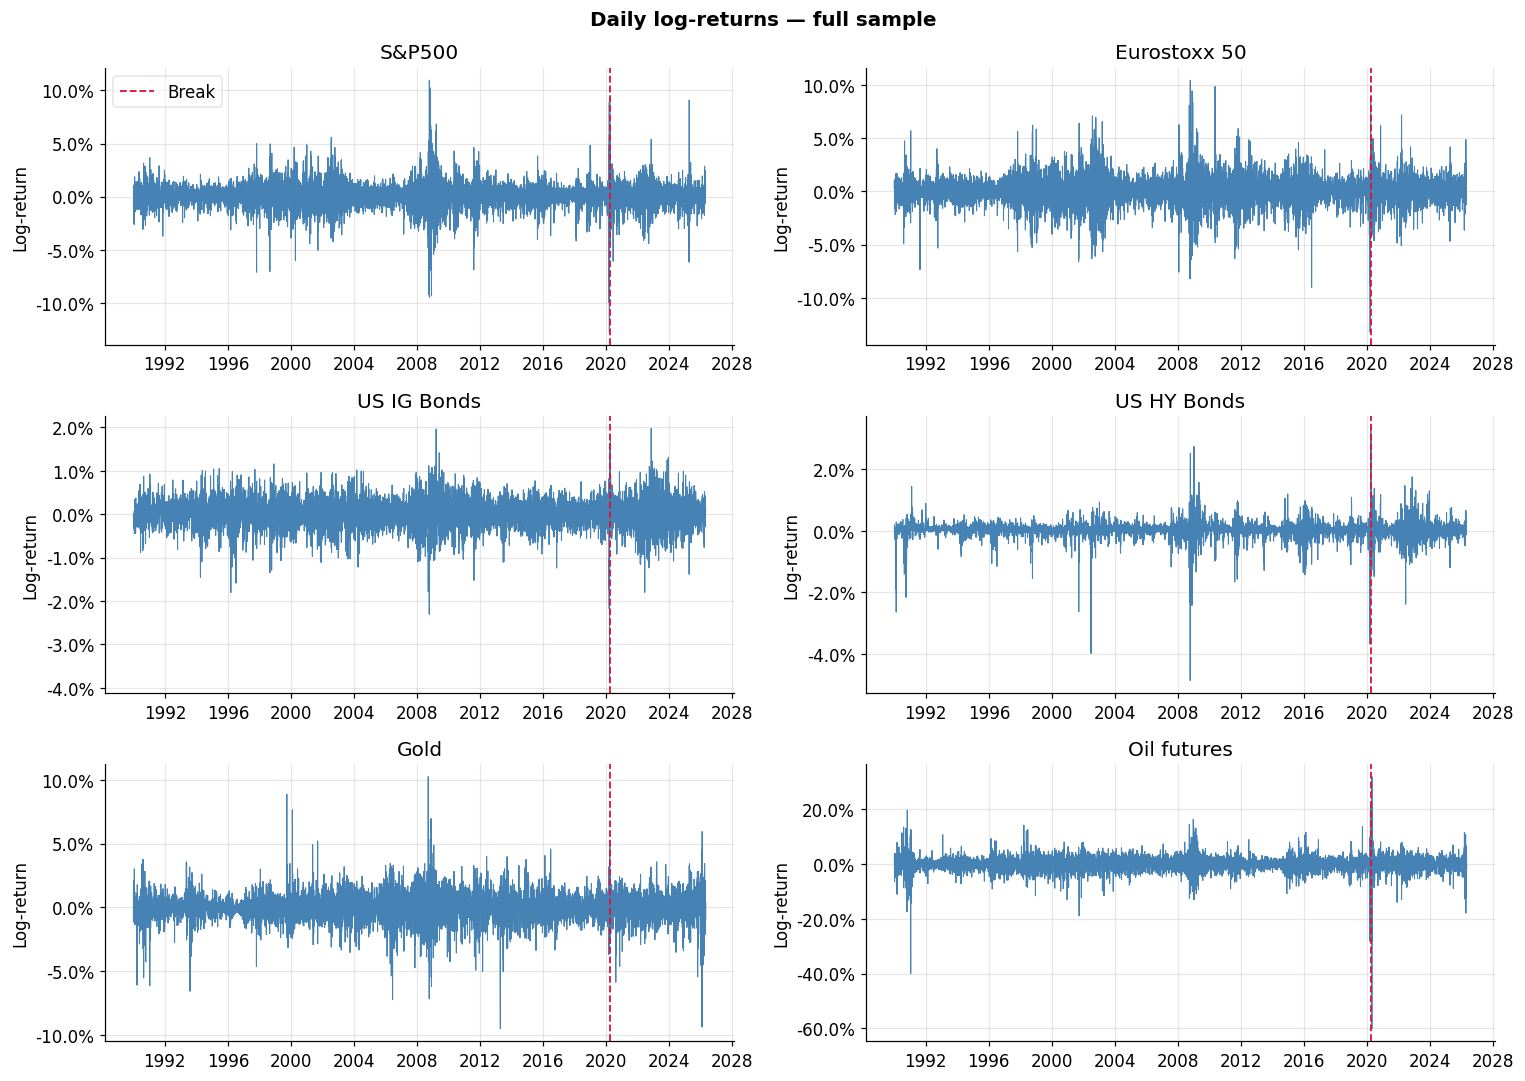

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax = axes[i]
    ax.plot(returns.index, returns[col], lw=0.7, color="steelblue")
    ax.axvline(COVID_DATE, color="crimson", lw=1.2, linestyle="--", label="Break")
    ax.set_title(col)
    ax.set_ylabel("Log-return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

axes[0].legend(framealpha=0.5)
fig.suptitle("Daily log-returns — full sample", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Descriptive statistics

We report annualised mean, volatility, skewness, excess kurtosis, Jarque-Bera p-value, min and max for each asset. All series are expected to reject normality (Cont 2001).

In [26]:
def summary_stats(r):
    if isinstance(r, pd.Series):
        r = r.to_frame()
    rows = []
    for col in r.columns:
        s = r[col].dropna()
        jb_stat, jb_p = stats.jarque_bera(s)
        adf_p = adfuller(s, autolag="AIC")[1]
        rows.append({
            "mean_ann"    : s.mean() * ANNUALIZATION,
            "vol_ann"     : s.std()  * np.sqrt(ANNUALIZATION),
            "skewness"    : round(float(stats.skew(s)), 3),
            "ex_kurtosis" : round(float(stats.kurtosis(s)), 3),
            "jb_pval"     : round(jb_p, 4),
            "min"         : round(s.min(), 4),
            "max"         : round(s.max(), 4),
            "adf_pval"    : round(adf_p, 4),
        })
    return pd.DataFrame(rows, index=r.columns)

summary_stats(returns).round(4)

,mean_ann,vol_ann,skewness,ex_kurtosis,jb_pval,min,max,adf_pval
S&P500,0.0785,0.1761,-0.367,11.541,0.0,-0.1277,0.1096,0.0
Eurostoxx 50,0.0441,0.2038,-0.254,6.870,0.0,-0.1324,0.1044,0.0
US IG Bonds,0.0548,0.0494,-0.585,5.855,0.0,-0.0383,0.0198,0.0
US HY Bonds,0.0707,0.0439,-2.406,42.669,0.0,-0.0487,0.0332,0.0
Gold,0.0648,0.1578,-0.295,8.095,0.0,-0.0951,0.1025,0.0
Oil futures,0.0372,0.4093,-1.753,49.676,0.0,-0.6017,0.3196,0.0


### Pre vs post comparison

In [27]:
stats_pre  = summary_stats(pre).add_suffix("_pre")
stats_post = summary_stats(post).add_suffix("_post")

comparison = pd.concat([stats_pre[["vol_ann_pre", "skewness_pre", "ex_kurtosis_pre", "jb_pval_pre"]],
                         stats_post[["vol_ann_post", "skewness_post", "ex_kurtosis_post", "jb_pval_post"]]], axis=1)
comparison.round(4)

,vol_ann_pre,skewness_pre,ex_kurtosis_pre,jb_pval_pre,vol_ann_post,skewness_post,ex_kurtosis_post,jb_pval_post
S&P500,0.1757,-0.515,12.221,0.0,0.1782,0.329,8.259,0.0
Eurostoxx 50,0.2077,-0.310,6.950,0.0,0.1835,0.180,5.509,0.0
US IG Bonds,0.0473,-0.824,7.322,0.0,0.0587,0.084,1.937,0.0
US HY Bonds,0.0421,-3.739,53.281,0.0,0.0523,1.126,15.738,0.0
Gold,0.1549,-0.193,8.471,0.0,0.1715,-0.689,6.651,0.0
Oil futures,0.3806,-0.937,20.260,0.0,0.5289,-3.143,78.977,0.0


### Volatility comparison — pre vs post

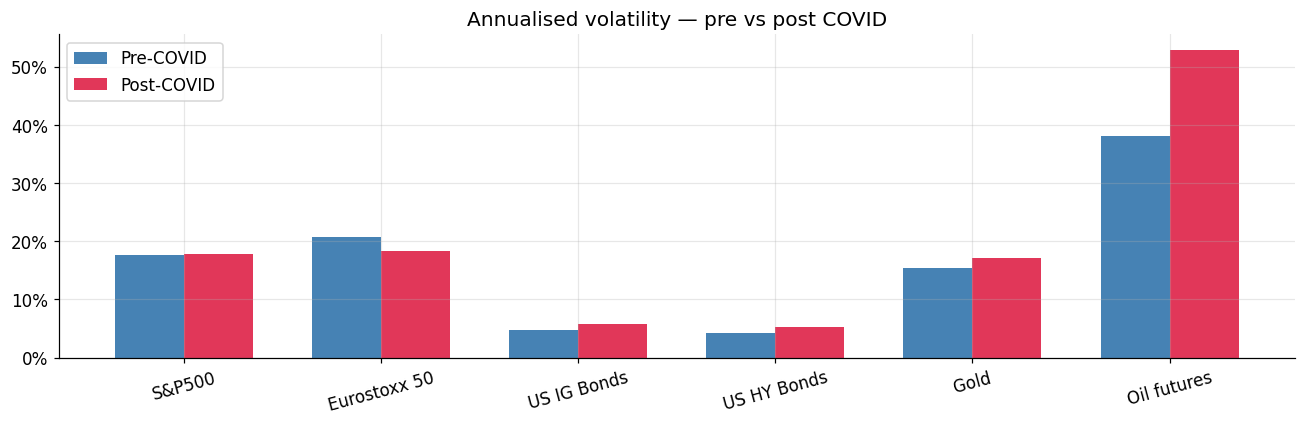

In [28]:
vol_pre  = pre.std()  * np.sqrt(ANNUALIZATION)
vol_post = post.std() * np.sqrt(ANNUALIZATION)

x = np.arange(len(ASSETS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID",  color="steelblue")
ax.bar(x + width/2, vol_post, width, label="Post-COVID", color="crimson", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ASSETS, rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Annualised volatility — pre vs post COVID")
ax.legend()
plt.tight_layout()
plt.show()

### Static correlations — pre vs post

The correlation matrix is the first, unconditional look at co-movement. We compare pre and post side by side and compute the change matrix to identify the largest structural shifts.

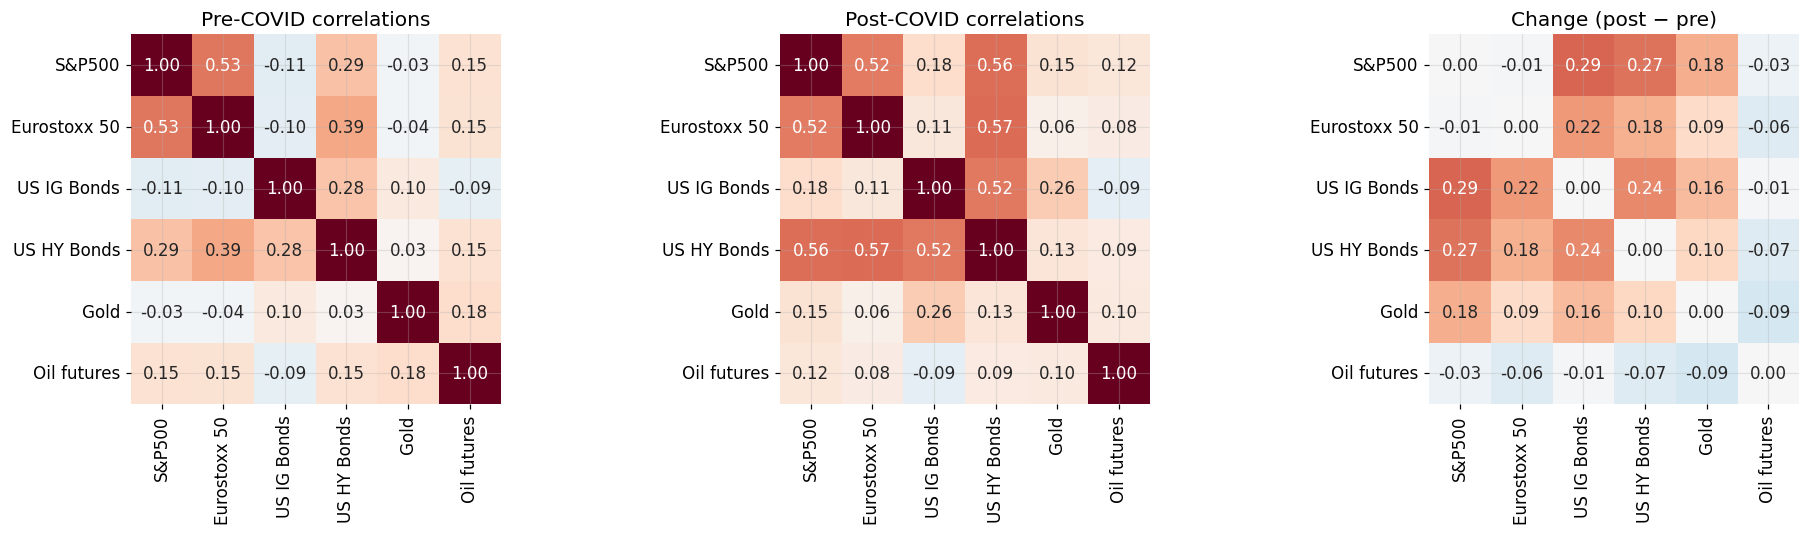

In [29]:
corr_pre  = pre.corr()
corr_post = post.corr()
corr_diff = corr_post - corr_pre

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar=False)

sns_kw = {**kw}
import seaborn as sns
sns.heatmap(corr_pre,  ax=axes[0], **kw)
sns.heatmap(corr_post, ax=axes[1], **kw)
sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-0.5, vmax=0.5, square=True, cbar=False)

axes[0].set_title("Pre-COVID correlations")
axes[1].set_title("Post-COVID correlations")
axes[2].set_title("Change (post − pre)")
plt.tight_layout()
plt.show()

### Stylized fact 1 — volatility clustering

The ACF of squared returns should be large and persistent. The ACF of raw returns should be near zero. Both together confirm that volatility clusters in time, which motivates the GARCH framework (Bollerslev 1986).

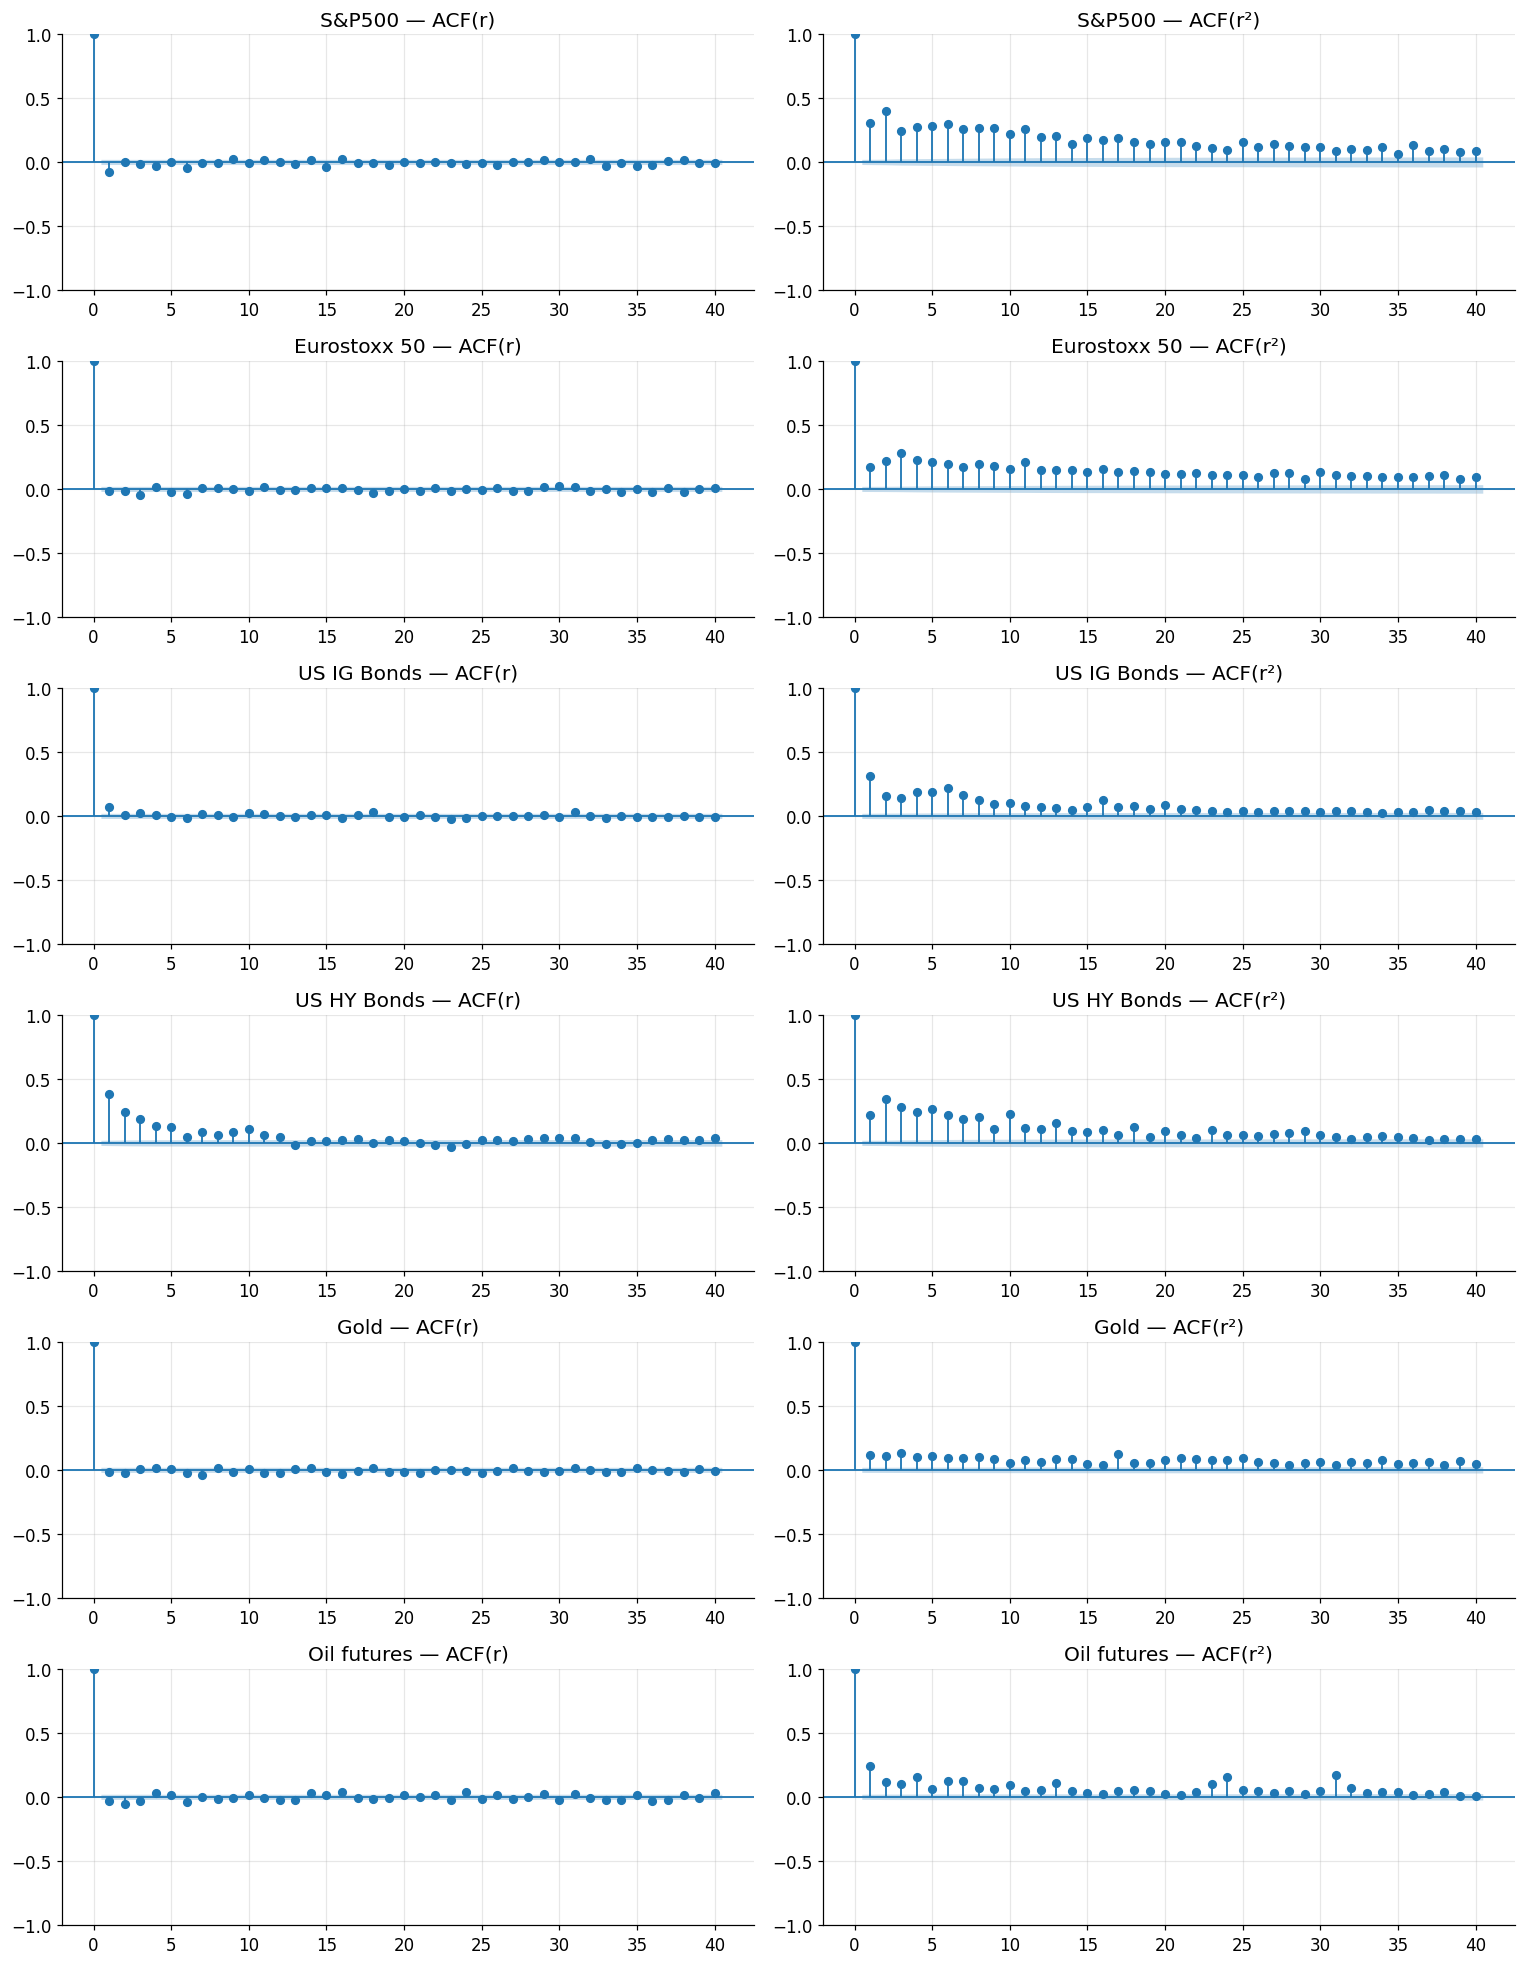

In [30]:
fig, axes = plt.subplots(len(ASSETS), 2, figsize=(14, 3 * len(ASSETS)))

for i, col in enumerate(ASSETS):
    r = returns[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{col} — ACF(r)")
    plot_acf(r**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{col} — ACF(r²)")

from statsmodels.graphics.tsaplots import plot_acf
plt.tight_layout()
plt.show()

### Stylized fact 2 — fat tails and non-normality

Jarque-Bera tests confirm all six series reject normality. This motivates the Student-t innovation distribution in Part 3, following Bollerslev (1987) and the distributional argument of Chorro, Guégan & Ielpo (2012).

In [31]:
print(f"{'Asset':<20}  {'JB statistic':>14}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    jb, p = stats.jarque_bera(r)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {jb:>14,.1f}  {p:>9.4f}  {reject:>10}")

Asset                   JB statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      53,484.9     0.0000     Yes ***
Eurostoxx 50                18,979.3     0.0000     Yes ***
US IG Bonds                 14,261.7     0.0000     Yes ***
US HY Bonds                737,506.2     0.0000     Yes ***
Gold                        26,345.3     0.0000     Yes ***
Oil futures                991,800.4     0.0000     Yes ***


### Stylized fact 3 — formal ARCH-LM test

Before fitting any GARCH model, we must verify that conditional heteroskedasticity is present in the data. The Engle (1982) ARCH-LM test tests H₀: no ARCH effects. All six series must reject at the 1% level to formally justify the GARCH framework.

In [32]:
print(f"{'Asset':<20}  {'LM statistic':>13}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    lm, p, _, _ = het_arch(r, nlags=10)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {lm:>13.2f}  {p:>9.4f}  {reject:>10}")

Asset                  LM statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      2390.65     0.0000     Yes ***
Eurostoxx 50                1508.38     0.0000     Yes ***
US IG Bonds                 1432.61     0.0000     Yes ***
US HY Bonds                 1954.61     0.0000     Yes ***
Gold                         551.94     0.0000     Yes ***
Oil futures                  937.53     0.0000     Yes ***


### Preliminary PCA on raw returns

Before GARCH filtering, we take a first look at the factor structure. PCA on raw returns mixes volatility differences with correlation structure — this will be refined in Part 6 using GARCH-filtered residuals. Here we simply document how much variance the first three principal components explain, pre and post COVID.

An increase in the variance explained by PC1 post-COVID would indicate that the six assets started moving more in tandem — risk became more concentrated in a single common factor. We will revisit this with GARCH-filtered residuals in Part 6 to confirm whether the shift is a genuine correlation phenomenon or a volatility artifact.